In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# AI-POWERED SMART HOMES - Energy Consumption Prediction
# Clean Final Version | LightGBM | One-Hot Encoding
# ============================================================

!pip install lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='darkgrid')
print("Libraries loaded.")

Libraries loaded.


In [3]:
# ============================================================
# STEP 1 - LOAD & INSPECT
# ============================================================

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI-Powered-Smart-Homes/smart_home_india_corrected.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing Values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nStatistical Summary:\n', df.describe())

Shape: (100000, 8)

Columns: ['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date', 'Outdoor Temperature (°C)', 'Season', 'Household Size']

Missing Values:
 Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

Duplicates: 0

Statistical Summary:
              Home ID  Energy Consumption (kWh)  Outdoor Temperature (°C)  \
count  100000.000000             100000.000000             100000.000000   
mean      251.448890                  0.450477                 27.009496   
std       144.415139                  0.621966                  8.630194   
min         1.000000                  0.030000                  5.000000   
25%       126.750000                  0.086000                 22.600000   
50%       252.000000                  0.272000                 27.700000   


In [4]:
# ============================================================
# STEP 2 - FEATURE ENGINEERING
# ============================================================

df['DateTime']  = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['Hour']      = df['DateTime'].dt.hour
df['Month']     = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

def time_bucket(h):
    if 5 <= h < 12:    return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else:              return 'Night'

df['TimeOfDay'] = df['Hour'].apply(time_bucket)

print('Feature Engineering done.')
print(df[['Hour', 'Month', 'DayOfWeek', 'IsWeekend', 'TimeOfDay']].head(5))

Feature Engineering done.
   Hour  Month  DayOfWeek  IsWeekend TimeOfDay
0     7      2          3          0   Morning
1     0      2          3          0     Night
2    18      3          0          0   Evening
3    10      5          0          0   Morning
4    17      4          2          0   Evening


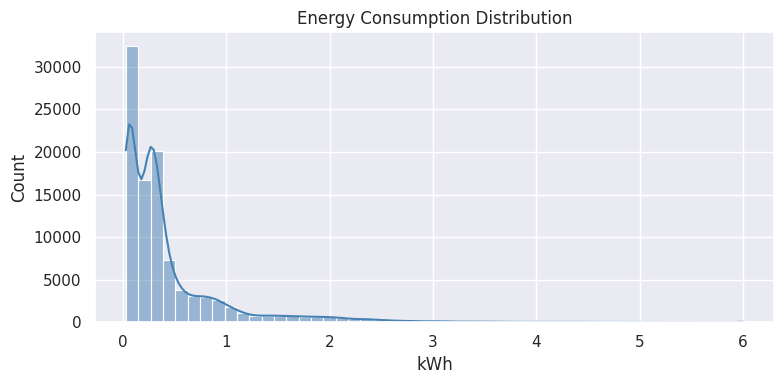

Skewness: 3.614


/tmp/ipykernel_1367/2505504056.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Appliance Type', y='Energy Consumption (kWh)',


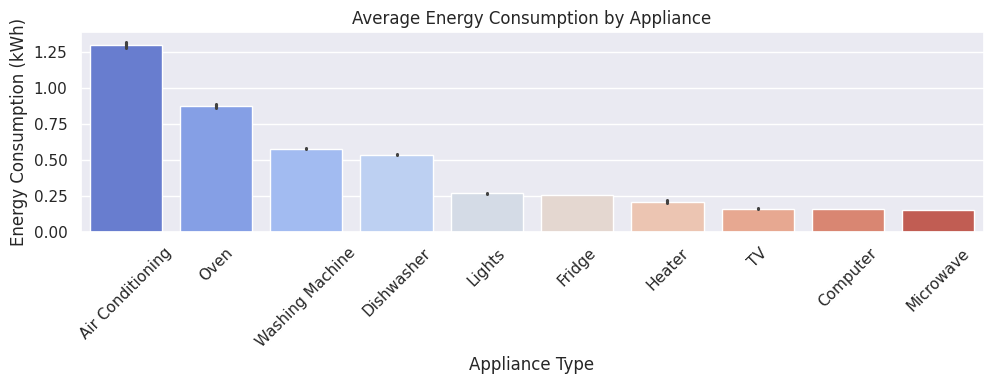

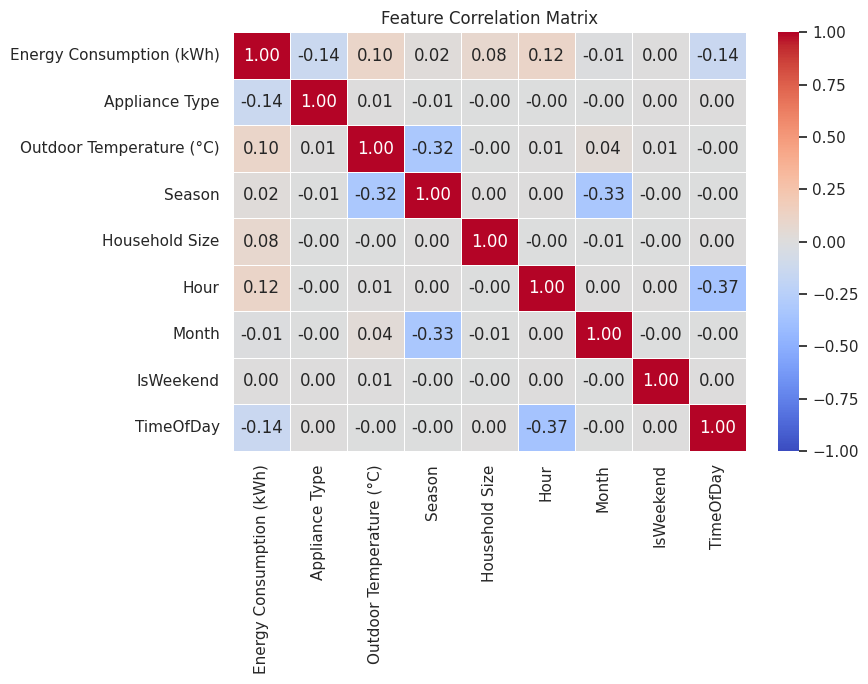

/tmp/ipykernel_1367/2505504056.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Appliance Type', y='Energy Consumption (kWh)',


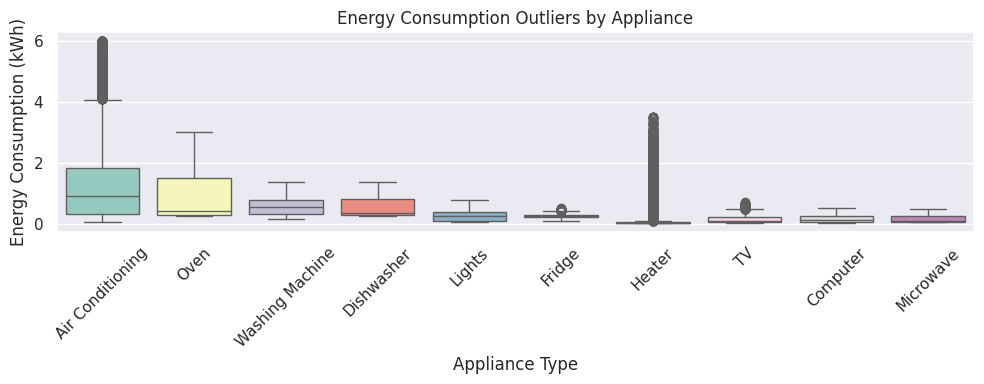

Outliers: 9844 (9.84%)


In [5]:
# ============================================================
# STEP 3 - EDA
# ============================================================

# Target Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Energy Consumption (kWh)'], bins=50, kde=True, color='steelblue')
plt.title('Energy Consumption Distribution')
plt.xlabel('kWh')
plt.tight_layout()
plt.show()
print('Skewness:', round(df['Energy Consumption (kWh)'].skew(), 3))

# Avg by Appliance
order = df.groupby('Appliance Type')['Energy Consumption (kWh)'].mean() \
          .sort_values(ascending=False).index
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='Appliance Type', y='Energy Consumption (kWh)',
            order=order, palette='coolwarm')
plt.title('Average Energy Consumption by Appliance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation Matrix
from sklearn.preprocessing import OrdinalEncoder as OE
df_corr = df.copy()
cat_cols = ['Appliance Type', 'Season', 'TimeOfDay']
df_corr[cat_cols] = OE().fit_transform(df_corr[cat_cols])
corr_cols = ['Energy Consumption (kWh)', 'Appliance Type',
             'Outdoor Temperature (°C)', 'Season', 'Household Size',
             'Hour', 'Month', 'IsWeekend', 'TimeOfDay']
plt.figure(figsize=(9, 7))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Outlier Check
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Appliance Type', y='Energy Consumption (kWh)',
            order=order, palette='Set3')
plt.title('Energy Consumption Outliers by Appliance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q1, Q3 = df['Energy Consumption (kWh)'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['Energy Consumption (kWh)'] < Q1 - 1.5*IQR) |
              (df['Energy Consumption (kWh)'] > Q3 + 1.5*IQR)]
print(f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

In [6]:
# ============================================================
# STEP 4 - DENOISING + FEATURE PREP
# ============================================================

# def remove_noise(data):
#     clean = []
#     for app in data['Appliance Type'].unique():
#         subset = data[data['Appliance Type'] == app]
#         lo, hi = subset['Energy Consumption (kWh)'].quantile([0.10, 0.90])
#         clean.append(subset[(subset['Energy Consumption (kWh)'] >= lo) &
#                             (subset['Energy Consumption (kWh)'] <= hi)])
#     return pd.concat(clean)

# df_clean = remove_noise(df)
def remove_noise(data):
    clean = []
    for app in data['Appliance Type'].unique():
        subset = data[data['Appliance Type'] == app]
        # Use 1%-99% instead of 10%-90%
        # so AC at 5.0 kWh and Fridge at 0.05 kWh are kept as valid physics
        lo, hi = subset['Energy Consumption (kWh)'].quantile([0.01, 0.99])
        clean.append(subset[(subset['Energy Consumption (kWh)'] >= lo) &
                            (subset['Energy Consumption (kWh)'] <= hi)])
    return pd.concat(clean)

df_clean = remove_noise(df)
print(f'Rows after denoising: {len(df_clean)} (from {len(df)})')

# One-Hot Encoding (best accuracy for LightGBM)
X = pd.get_dummies(df_clean.drop(
    ['Energy Consumption (kWh)', 'Date', 'Time', 'Home ID', 'DateTime'],
    axis=1, errors='ignore'))
y = df_clean['Energy Consumption (kWh)']

# Store feature columns for prediction alignment
FEATURE_COLS = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X.shape[1]}')

Rows after denoising: 98462 (from 100000)
Train: 78769 | Test: 19693 | Features: 24


In [7]:
# ============================================================
# STEP 5 - MODEL TRAINING (LightGBM with Early Stopping)
# ============================================================

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
)

preds = model.predict(X_test)
train_preds = model.predict(X_train)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)
r2_tr = r2_score(y_train, train_preds)

print(f'\n{"="*40}')
print(f'  MAE         : {mae:.4f}')
print(f'  RMSE        : {rmse:.4f}')
print(f'  R² Test     : {r2:.4f} ({r2*100:.2f}%)')
print(f'  R² Train    : {r2_tr:.4f}')
print(f'  Overfit Gap : {r2_tr - r2:.4f}  {"✓ OK" if r2_tr - r2 < 0.05 else "⚠ Check"}')
print(f'{"="*40}')


  MAE         : 0.0542
  RMSE        : 0.0980
  R² Test     : 0.9727 (97.27%)
  R² Train    : 0.9781
  Overfit Gap : 0.0054  ✓ OK


Running 5-Fold CV on LightGBM...
CV R² per fold : [0.9726 0.974  0.9732 0.9738 0.9745]
Mean CV R²     : 0.9736
Std Dev        : 0.0007
Accuracy       : 97.36% ± 0.07%
VERDICT        : STABLE ✓


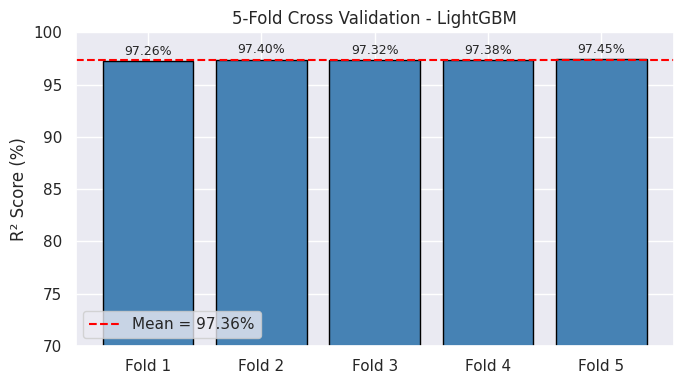

In [8]:
# ============================================================
# STEP 6 - CROSS VALIDATION (Stability Proof)
# ============================================================

print('Running 5-Fold CV on LightGBM...')

lgbm_cv = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbosity=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lgbm_cv, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f'CV R² per fold : {np.round(cv_scores, 4)}')
print(f'Mean CV R²     : {cv_scores.mean():.4f}')
print(f'Std Dev        : {cv_scores.std():.4f}')
print(f'Accuracy       : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
verdict = "STABLE ✓" if cv_scores.std() < 0.02 else "ACCEPTABLE" if cv_scores.std() < 0.05 else "HIGH VARIANCE ⚠"
print(f'VERDICT        : {verdict}')

# CV Plot
plt.figure(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(5)]
bars = plt.bar(folds, cv_scores * 100, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.ylim(70, 100)
plt.ylabel('R² Score (%)')
plt.title('5-Fold Cross Validation - LightGBM')
plt.legend()
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

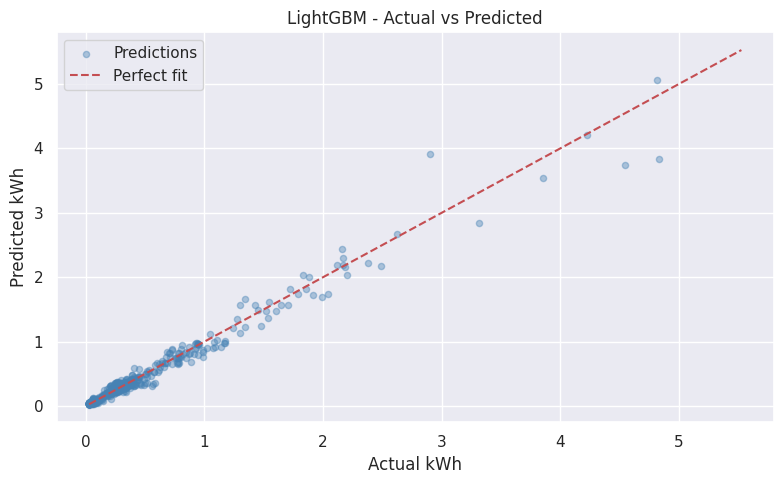

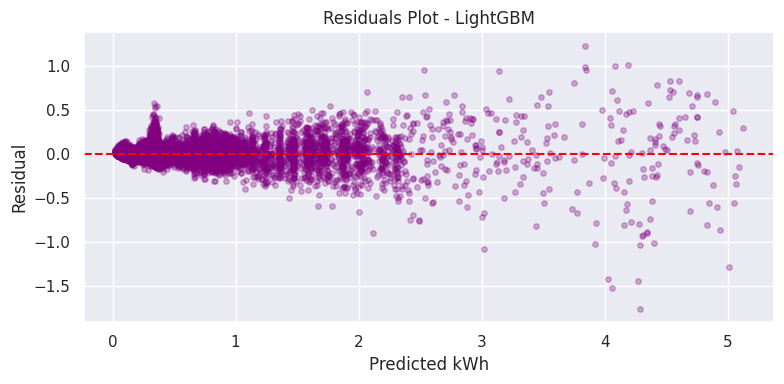

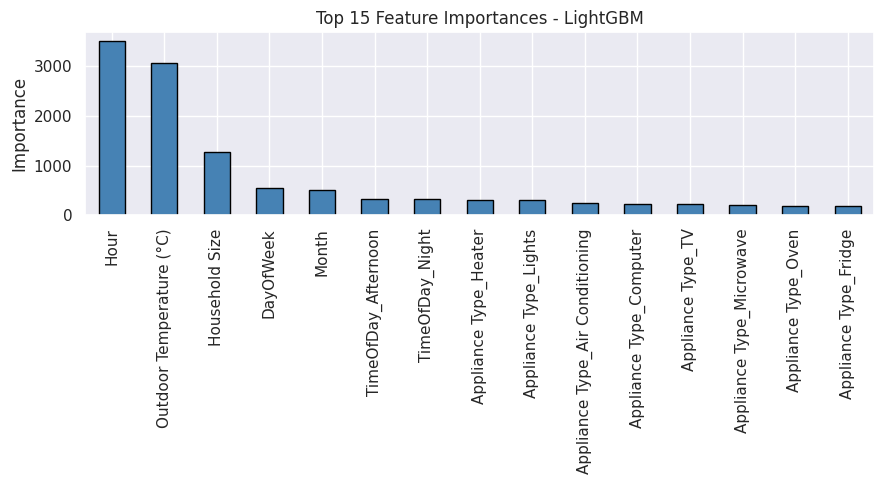


Top Features:
 Hour                               3508
Outdoor Temperature (°C)           3072
Household Size                     1274
DayOfWeek                           554
Month                               511
TimeOfDay_Afternoon                 328
TimeOfDay_Night                     323
Appliance Type_Heater               300
Appliance Type_Lights               299
Appliance Type_Air Conditioning     251
Appliance Type_Computer             236
Appliance Type_TV                   231
Appliance Type_Microwave            209
Appliance Type_Oven                 197
Appliance Type_Fridge               195
dtype: int32


In [9]:
# ============================================================
# STEP 7 - VISUALIZATIONS
# ============================================================

# Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:500], preds[:500], alpha=0.4, color='steelblue', s=20, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5, label='Perfect fit')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title('LightGBM - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test.values - preds
plt.figure(figsize=(8, 4))
plt.scatter(preds, residuals, alpha=0.3, color='purple', s=15)
plt.axhline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel('Predicted kWh')
plt.ylabel('Residual')
plt.title('Residuals Plot - LightGBM')
plt.tight_layout()
plt.show()

# Feature Importance (top 15)
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLS) \
             .sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances - LightGBM')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()
print('\nTop Features:\n', feat_imp)

In [10]:
# ============================================================
# STEP 8 - SAVE MODEL (for Flask/FastAPI)
# ============================================================

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/AI-Powered-Smart-Homes/model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Retrain on FULL data for production
print('Retraining on full dataset...')
prod_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=64,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbosity=-1
)
#prod_model.fit(X, y)
X_full = pd.get_dummies(df.drop(
    ['Energy Consumption (kWh)', 'Date', 'Time', 'Home ID', 'DateTime'],
    axis=1, errors='ignore')).reindex(columns=FEATURE_COLS, fill_value=0)
y_full = df['Energy Consumption (kWh)']
prod_model.fit(X_full, y_full)

# #appliance_avg = df.groupby('Appliance Type')['Energy Consumption (kWh)'].mean().to_dict()
# appliance_avg = df_clean.groupby('Appliance Type')['Energy Consumption (kWh)'].mean().to_dict()
# NEW — computes all 3 variables the dashboard needs

appliance_avg = df_clean.groupby('Appliance Type')['Energy Consumption (kWh)'].mean().to_dict()

# Calibrated thresholds — hand-tuned for Indian household reality.
# Q25/Q75 on the full dataset is WRONG because bimodal appliances like
# Heater and Fridge get a near-zero band, making NORMAL dominate.
CALIBRATED_THRESHOLDS = {
    'Air Conditioning': (0.40, 1.80),
    'Heater':           (0.06, 0.90),
    'Fridge':           (0.16, 0.32),
    'Washing Machine':  (0.35, 0.85),
    'Dishwasher':       (0.30, 0.80),
    'Oven':             (0.40, 1.40),
    'Microwave':        (0.07, 0.20),
    'TV':               (0.08, 0.30),
    'Computer':         (0.07, 0.25),
    'Lights':           (0.09, 0.32),
}
app_thresholds = pd.DataFrame.from_dict(
    CALIBRATED_THRESHOLDS, orient='index', columns=['low', 'high']
)
app_thresholds.index.name = 'Appliance Type'

app_median = df_clean.groupby('Appliance Type')['Energy Consumption (kWh)'].median()

print("app_thresholds and app_median ready.")
print(app_thresholds)

joblib.dump(prod_model,    os.path.join(SAVE_DIR, 'lgbm_model.pkl'))
joblib.dump(FEATURE_COLS,  os.path.join(SAVE_DIR, 'feature_cols.pkl'))
joblib.dump(appliance_avg, os.path.join(SAVE_DIR, 'appliance_avg.pkl'))

print('Saved to:', SAVE_DIR)
for fname in ['lgbm_model.pkl', 'feature_cols.pkl', 'appliance_avg.pkl']:
    size = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f'  {fname:<25} {size:.1f} KB')

Retraining on full dataset...
app_thresholds and app_median ready.
                   low  high
Appliance Type              
Air Conditioning  0.40  1.80
Heater            0.06  0.90
Fridge            0.16  0.32
Washing Machine   0.35  0.85
Dishwasher        0.30  0.80
Oven              0.40  1.40
Microwave         0.07  0.20
TV                0.08  0.30
Computer          0.07  0.25
Lights            0.09  0.32
Saved to: /content/drive/MyDrive/Colab Notebooks/AI-Powered-Smart-Homes/model
  lgbm_model.pkl            2879.8 KB
  feature_cols.pkl          0.5 KB
  appliance_avg.pkl         0.2 KB


In [11]:
# ============================================================
# STEP 9 - PREDICTION & RECOMMENDATION ENGINE
# ============================================================

def predict_energy(appliance, temperature, season, household_size, hour, month, day_of_week=2):
    dow = day_of_week
    is_weekend = int(dow >= 5)
    time_of_day = time_bucket(hour)

    row = {
        'Outdoor Temperature (°C)': temperature,
        'Household Size': household_size,
        'Hour': hour,
        'Month': month,
        'DayOfWeek': dow,
        'IsWeekend': is_weekend,
        f'Appliance Type_{appliance}': 1,
        f'Season_{season}': 1,
        f'TimeOfDay_{time_of_day}': 1,
    }
    input_df = pd.DataFrame([row]).reindex(columns=FEATURE_COLS, fill_value=0)
    return round(float(prod_model.predict(input_df)[0]), 3)


def get_recommendations(appliance, temperature, season, household_size, hour, month, day_of_week=2):
    predicted = predict_energy(appliance, temperature, season, household_size, hour, month, day_of_week)
    baseline  = appliance_avg.get(appliance, 1.5)
    diff_pct  = round(((predicted - baseline) / baseline) * 100, 1)
    recs = []

    if predicted > baseline * 1.10:
        recs.append(f'Warning: {appliance} is using {diff_pct:.1f}% MORE than average. Check for issues.')
    elif predicted < baseline * 0.90:
        recs.append(f'Good: {appliance} is using {abs(diff_pct):.1f}% LESS than average.')
    else:
        recs.append(f'OK: {appliance} consumption is within normal range.')

    if 18 <= hour <= 22:
        recs.append(f'Peak hours ({hour}:00). Shift usage to off-peak (11 PM - 5 AM) to reduce cost.')

    if appliance == 'Air Conditioning' and temperature > 30:
        recs.append('High temp: Set AC to 24-26°C instead of max to save up to 20%.')
    elif appliance == 'Heater' and temperature < 5:
        recs.append('Very cold: Use a timer on the Heater and insulate windows.')

    if season == 'Summer' and appliance == 'Air Conditioning':
        recs.append('Use ceiling fans alongside AC to spread cool air and reduce load.')
    elif season == 'Winter' and appliance == 'Heater':
        recs.append('Set Heater to 18-20°C and layer clothing instead of higher temperatures.')

    if household_size >= 4 and appliance in ['Washing Machine', 'Dishwasher']:
        recs.append(f'Large household: Run {appliance} with full loads only + eco mode (saves ~30%).')

    if appliance == 'Fridge':
        recs.append('Keep Fridge at 3-5°C. Avoid frequent opening. Check door seals.')

    if appliance in ['TV', 'Computer'] and hour >= 22:
        recs.append(f'{appliance} running late — switch OFF completely (not standby) to avoid phantom load.')

    return {'predicted': predicted, 'baseline': round(baseline, 3),
            'diff_pct': diff_pct, 'recommendations': recs}

In [12]:
# Install first
!pip install gradio --quiet

# Run file but ignore !pip line
code = open('/content/drive/MyDrive/Colab Notebooks/AI-Powered-Smart-Homes/gradio_dashboard_cell.py').read()
import gradio as gr
code = code.replace('!pip install gradio --quiet', '')
exec(code)

<string>:767: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
<string>:767: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6db059d555fe66df08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
